# XGBoost Forecast for electricity_local
This notebook builds an XGBoost model to forecast electricity_local

## 1 — Import Required Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
from matplotlib.patches import Patch
import joblib

print('All libraries loaded successfully.')


All libraries loaded successfully.


## 2 — Configuration

In [2]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))

CANDIDATE_PATHS = [
    os.path.join(NOTEBOOK_DIR, 'combined_air_electricity_ipi_cleaned.csv'),
    os.path.join(NOTEBOOK_DIR, '..', 'COS40007DataCleaning', 'combined_air_electricity_ipi_cleaned.csv'),
    os.path.join(NOTEBOOK_DIR, '..', 'public', 'data', 'combined_air_electricity_ipi_cleaned.csv'),
]
FILE_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if FILE_PATH is None:
    raise FileNotFoundError('Could not find combined_air_electricity_ipi_cleaned.csv')

TARGET_COL  = 'electricity_local'    
TEST_SIZE   = 12               
LOOKBACK    = 4                
SEED        = 42

# Best hyperparameters (validated on this target column)
BEST_PARAMS = {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'reg_lambda': 0.1, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'verbosity': 0}

## 3 — Load CSV Dataset

In [3]:
df = pd.read_csv(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Forecast target: {TARGET_COL}')
print(f'Dataset shape before outlier removal: {df.shape}')
print('First 5 rows:')
print(df[['date', TARGET_COL]].head())
print('Last 5 rows:')
print(df[['date', TARGET_COL]].tail())


Forecast target: electricity_local
Dataset shape before outlier removal: (60, 20)
First 5 rows:
        date  electricity_local
0 2018-01-01       11845.900250
1 2018-02-01       11091.957006
2 2018-03-01       12244.089947
3 2018-04-01       12018.584577
4 2018-05-01       12267.998390
Last 5 rows:
         date  electricity_local
55 2022-08-01       13463.730428
56 2022-09-01       13090.583108
57 2022-10-01       13214.603633
58 2022-11-01       12934.276582
59 2022-12-01       13041.875463


## 4 — Outlier Smoothing (Z-Score, threshold = 3)
values with Z-score > 3 are replaced with NaN and linearly interpolated.


In [4]:
z_scores = np.abs(zscore(df[TARGET_COL]))
df[TARGET_COL] = np.where(z_scores > 3, np.nan, df[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].interpolate()

print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Total months after outlier smoothing: {len(df)}')
print(f'Outliers smoothed: {(z_scores > 3).sum()}')


Date range: 2018-01-01 00:00:00 to 2022-12-01 00:00:00
Total months after outlier smoothing: 60
Outliers smoothed: 1


## 5 — Log Transformation & ADF Stationarity Test

Result for electricity_local: Already stationary (ADF p=0.0003) → no differencing needed.


In [5]:
df.set_index('date', inplace=True)
df[f'log_{TARGET_COL}'] = np.log(df[TARGET_COL])
log_series = df[f'log_{TARGET_COL}']

# Force first-order differencing
processed_series = log_series.diff().dropna()
difference_order = 1

print(f"Log transformation applied.")
print(f"Forced first-order differencing applied.")

# Optional: You can keep the ADF test just to observe the stationarity, 
# but we no longer use it to decide the processing flow.
def run_adf_test(series, alpha=0.05):
    result = adfuller(series, autolag='AIC')
    print(f"ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    return result[1] <= alpha

print("\nADF test on final processed series:")
run_adf_test(processed_series)

print(f"\nFinal series uses log-transformed values with differencing order = {difference_order}.")
print(f"Final processed data length: {len(processed_series)}")

data = processed_series.values.reshape(-1, 1)
print(f"Data shape: {data.shape}")

Log transformation applied.
Forced first-order differencing applied.

ADF test on final processed series:
ADF statistic: -6.1918, p-value: 0.0000

Final series uses log-transformed values with differencing order = 1.
Final processed data length: 59
Data shape: (59, 1)


## 6 — Split Data into Train and Test (Last 12 Months)


In [6]:
train_data = data[:-TEST_SIZE]
test_data  = data[-TEST_SIZE:]

print(f'Train data shape: {train_data.shape}')
print(f'Test  data shape: {test_data.shape}')
print(f'Train range: {len(train_data)} months')
print(f'Test  range: {len(test_data)} months')


Train data shape: (47, 1)
Test  data shape: (12, 1)
Train range: 47 months
Test  range: 12 months


## 7 — Scale Data with MinMaxScaler After Split


In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f'Scaled train shape: {train_scaled.shape}')
print(f'Scaled test  shape: {test_scaled.shape}')
print(f'Scaler min: {scaler.data_min_[0]:.4f}, max: {scaler.data_max_[0]:.4f}')


Scaled train shape: (47, 1)
Scaled test  shape: (12, 1)
Scaler min: -0.1327, max: 0.1113


## 8 — Build Lag Features (Lookback = 3)

| Feature | Description |
|---|---|
| lag1 – lag3 | Past 3 scaled values (autoregressive) |
| roll_mean3 | 3-step rolling mean (local trend) |
| roll_std3 | 3-step rolling std (volatility) |
| month | Calendar month (seasonality) |


In [8]:
def create_features(scaled_data, dates_index, lookback):
    rows = []
    for i in range(lookback, len(scaled_data)):
        r = {}
        for lag in range(1, lookback + 1):
            r[f'lag{lag}'] = scaled_data[i - lag, 0]
        r['roll_mean3'] = np.mean(scaled_data[max(0, i-3):i, 0])
        r['roll_std3']  = np.std(scaled_data[max(0, i-3):i, 0])
        r['month']      = dates_index[i].month
        rows.append(r)
    feat_df = pd.DataFrame(rows, index=dates_index[lookback:])
    target  = scaled_data[lookback:, 0]
    return feat_df, target

test_extended = np.vstack((train_scaled[-LOOKBACK:], test_scaled))

# Build training features from train_scaled
X_train_feat, y_train_feat = create_features(
    train_scaled, processed_series.index[:len(train_data)], LOOKBACK
)

# Build test features from test_extended
test_ext_dates = processed_series.index[len(train_data) - LOOKBACK:]
X_test_feat, y_test_feat = create_features(test_extended, test_ext_dates, LOOKBACK)

FEATURE_COLS = X_train_feat.columns.tolist()

print(f'X_train shape: {X_train_feat.shape}')
print(f'X_test  shape: {X_test_feat.shape}')
print(f'Features: {FEATURE_COLS}')


X_train shape: (43, 7)
X_test  shape: (12, 7)
Features: ['lag1', 'lag2', 'lag3', 'lag4', 'roll_mean3', 'roll_std3', 'month']


## 9 — Walk-Forward Validation


In [9]:
def walk_forward_validation_xgb(train_scaled, dates_index, lookback=3,
                                  val_size=4, n_splits=3, initial_train_size=20):
    total_len = len(train_scaled)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError('Not enough data for walk-forward validation.')
    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end   = val_start + val_size
        if val_end > total_len:
            print(f'Fold {split + 1}: not enough data, skipping.')
            break

        train_window = train_scaled[:train_end]
        val_window   = train_scaled[val_start:val_end]
        window_dates = dates_index[:val_end]

        # Train portion features
        Xtr_w, ytr_w = create_features(train_window, window_dates[:train_end], lookback)

        val_ext       = np.vstack((train_window[-lookback:], val_window))
        val_ext_dates = dates_index[train_end - lookback:val_end]
        Xva_w, yva_w  = create_features(val_ext, val_ext_dates, lookback)

        fold_model = XGBRegressor(**BEST_PARAMS)
        fold_model.fit(Xtr_w, ytr_w)

        yva_pred = fold_model.predict(Xva_w)
        mse  = mean_squared_error(yva_w, yva_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(yva_w, yva_pred)
        metrics.append((mse, rmse, r2))
        print(f'Fold {split+1}: train_end={train_end}, val_end={val_end}, '
              f'MSE={mse:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}')

    return metrics

metrics = walk_forward_validation_xgb(
    train_scaled,
    processed_series.index[:len(train_data)],
    lookback=LOOKBACK, val_size=4, n_splits=3, initial_train_size=20
)

mse_vals  = [m[0] for m in metrics]
rmse_vals = [m[1] for m in metrics]
r2_vals   = [m[2] for m in metrics]

print('Walk-forward validation summary:')
print(f'Average MSE:  {np.mean(mse_vals):.6f}')
print(f'Average RMSE: {np.mean(rmse_vals):.6f}')
print(f'Average R²:   {np.mean(r2_vals):.6f}')


Fold 1: train_end=24, val_end=28, MSE=0.037373, RMSE=0.193321, R²=-6.162414
Fold 2: train_end=28, val_end=32, MSE=0.023767, RMSE=0.154165, R²=-1.964461
Fold 3: train_end=32, val_end=36, MSE=0.025072, RMSE=0.158341, R²=-0.833643
Walk-forward validation summary:
Average MSE:  0.028737
Average RMSE: 0.168609
Average R²:   -2.986839


## 10 — Train Final XGBoost Model on Full Training Set

In [10]:
print('Training final XGBoost model on the full training set...')

model = XGBRegressor(**BEST_PARAMS)
model.fit(X_train_feat, y_train_feat,
          eval_set=[(X_train_feat, y_train_feat), (X_test_feat, y_test_feat)],
          verbose=False)

print('Training completed!')


Training final XGBoost model on the full training set...
Training completed!


## 11 — Evaluate with MSE, RMSE, and R² (Scaled Data)


In [11]:
y_pred_scaled = model.predict(X_test_feat)

mse_scaled  = mean_squared_error(y_test_feat, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled   = r2_score(y_test_feat, y_pred_scaled)

print('=== Metrics on Scaled Data ===')
print(f'MSE (scaled):  {mse_scaled:.6f}')
print(f'RMSE (scaled): {rmse_scaled:.6f}')
print(f'R² (scaled):   {r2_scaled:.6f}')


=== Metrics on Scaled Data ===
MSE (scaled):  0.009022
RMSE (scaled): 0.094986
R² (scaled):   0.682354


## 12 — Inverse Scale Predictions


In [12]:

y_pred_diff_vals = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_diff_vals = scaler.inverse_transform(y_test_feat.reshape(-1, 1))

if difference_order == 0:
    y_pred_log_values = y_pred_diff_vals
    y_test_log_values = y_test_diff_vals

elif difference_order == 1:
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff_vals + prev1
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

else:  # difference_order == 2
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    prev2 = log_series.iloc[-TEST_SIZE - 2:-2].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff_vals + 2 * prev1 - prev2
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

y_pred_original = np.exp(y_pred_log_values)
y_test_original = np.exp(y_test_log_values)

assert y_pred_original.shape == y_test_original.shape, \
    f'Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}'
assert len(y_pred_original) == TEST_SIZE, \
    f'Expected {TEST_SIZE} predictions, got {len(y_pred_original)}'

mse_original  = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original   = r2_score(y_test_original, y_pred_original)

print('=== Metrics on Original Scale ===')
print(f'MSE  (original): {mse_original:.20f}')
print(f'RMSE (original): {rmse_original:.20f}')
print(f'R²   (original): {r2_original:.6f}')


=== Metrics on Original Scale ===
MSE  (original): 89687.46470360922103282064
RMSE (original): 299.47865483805225039760
R²   (original): 0.393488


## 13 Plot Prediction vs Actual
Car-forecast display layout: full history/test forecast, test detail, scatter, learning curves, feature importance. Figure is displayed inline only (not saved as PNG).


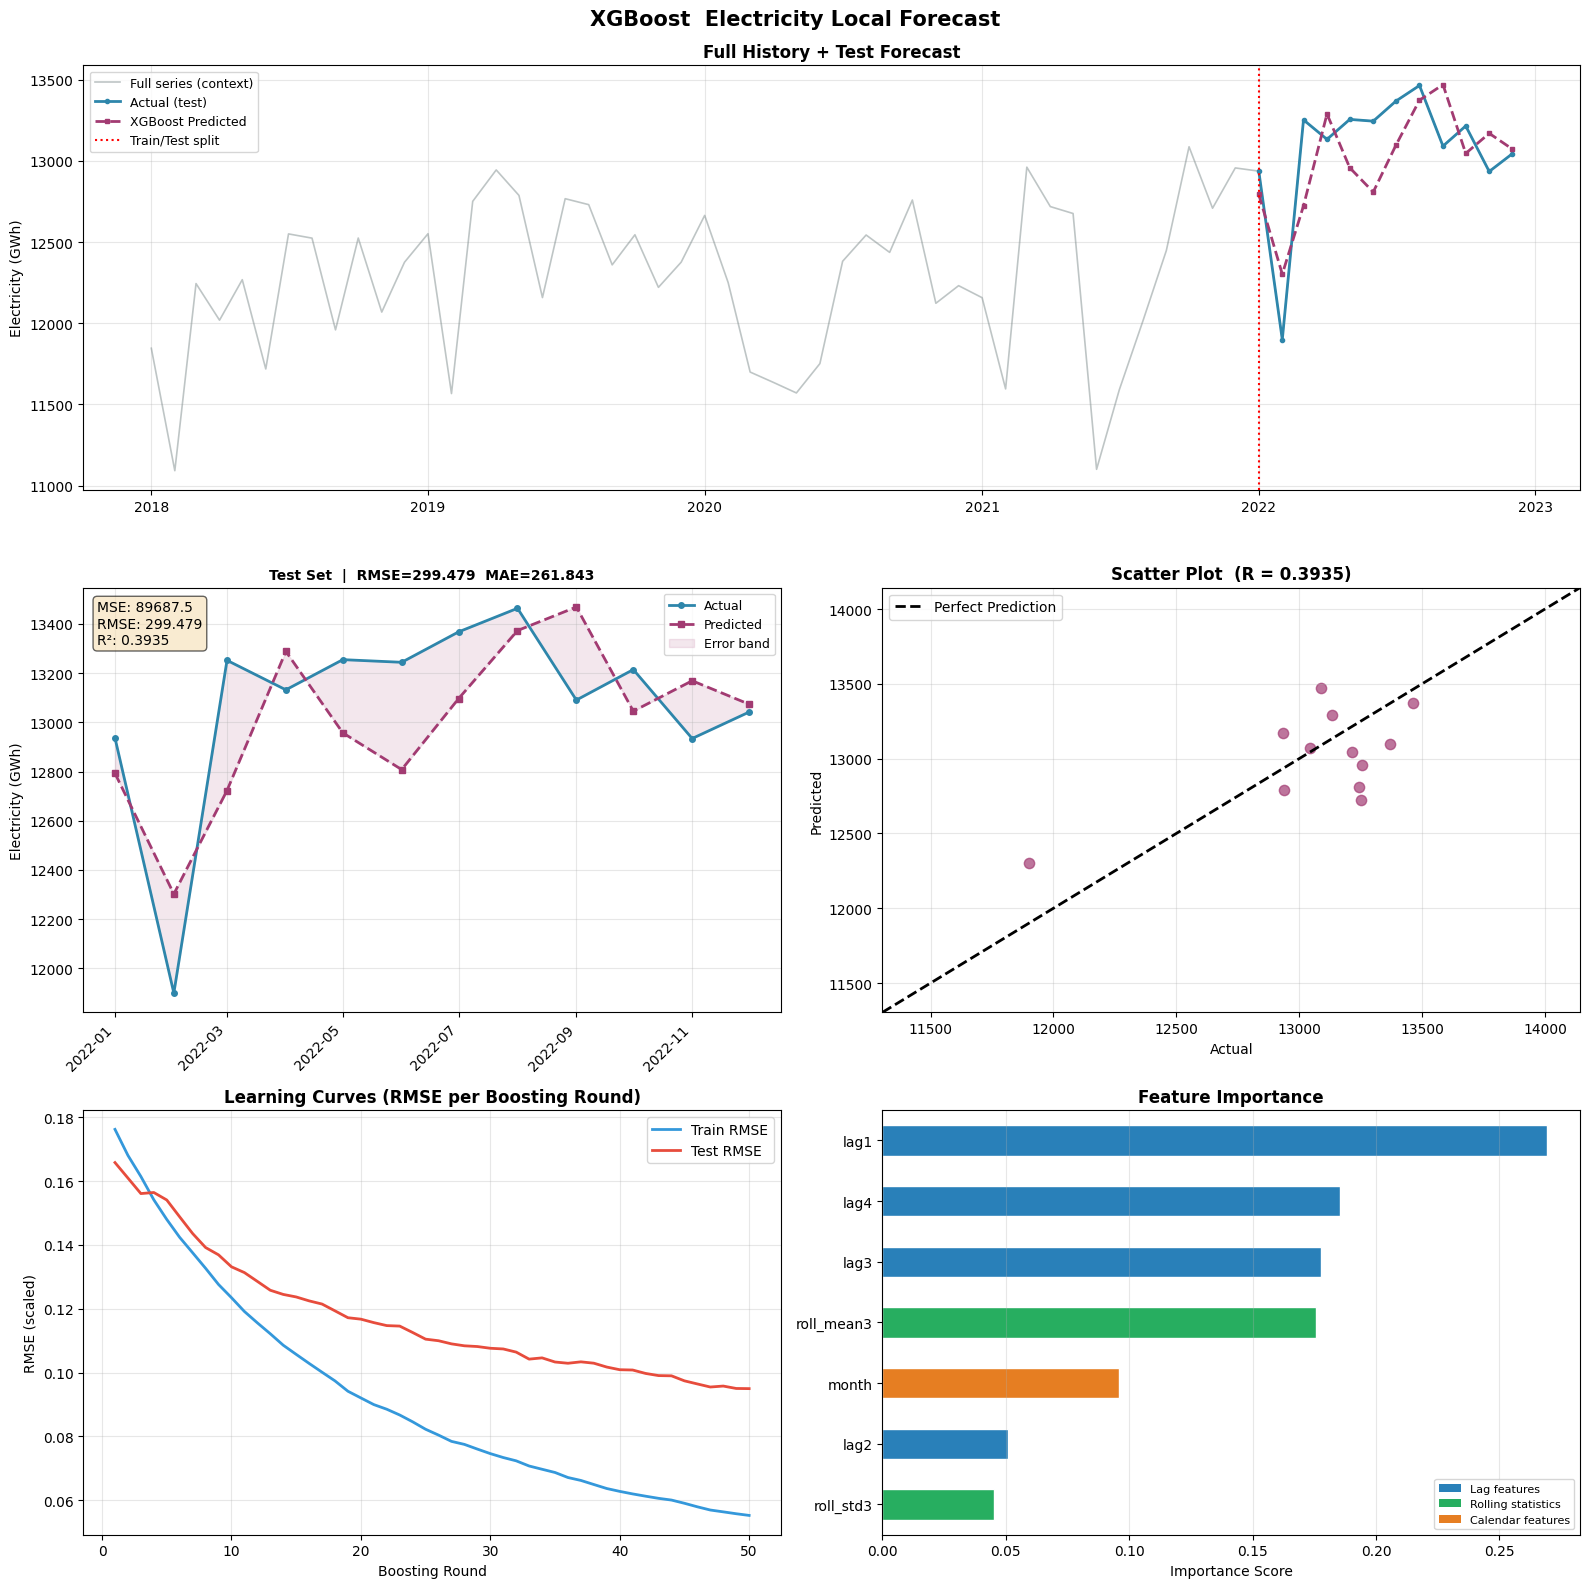


 XGBoost forecast completed.
Figure is displayed inline in the notebook only (no PNG file saved to disk).


In [13]:
test_dates  = processed_series.index[-TEST_SIZE:]
train_dates = X_train_feat.index
evals       = model.evals_result()
tr_curve    = evals['validation_0']['rmse']
te_curve    = evals['validation_1']['rmse']
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
imp_colors  = ['#2980b9' if 'lag' in f else
               '#27ae60' if 'roll' in f else '#e67e22'
               for f in importances.index]

mae_original = mean_absolute_error(y_test_original, y_pred_original)
y_axis_labels = {
    'air_no2': 'NO2 (ppm)',
    'electricity_local': 'Electricity (GWh)',
    'ipi_abs_index_sa': 'IPI Abs Index SA',
}
title_labels = {
    'air_no2': 'Air NO2',
    'electricity_local': 'Electricity Local',
    'ipi_abs_index_sa': 'IPI Absolute Index SA',
}
y_axis_label = y_axis_labels.get(TARGET_COL, TARGET_COL)
title_label = title_labels.get(TARGET_COL, TARGET_COL)

fig = plt.figure(figsize=(16, 16))
fig.suptitle(f'XGBoost  {title_label} Forecast',
             fontsize=15, fontweight='bold', y=0.99)

ax0 = fig.add_subplot(3, 2, (1, 2))
ax0.plot(df.index, df[TARGET_COL], color='#7f8c8d', lw=1.2,
         alpha=0.5, label='Full series (context)')
ax0.plot(test_dates, y_test_original.flatten(),
         color='#2E86AB', lw=2, marker='o', ms=3, label='Actual (test)')
ax0.plot(test_dates, y_pred_original.flatten(),
         color='#A23B72', lw=2, ls='--', marker='s', ms=3, label='XGBoost Predicted')
ax0.axvline(test_dates[0], color='red', ls=':', lw=1.5, label='Train/Test split')
ax0.set_title('Full History + Test Forecast', fontweight='bold')
ax0.set_ylabel(y_axis_label)
ax0.legend(fontsize=9); ax0.grid(alpha=0.3)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax1 = fig.add_subplot(3, 2, 3)
ax1.plot(test_dates, y_test_original.flatten(),
         color='#2E86AB', lw=2, marker='o', ms=4, label='Actual')
ax1.plot(test_dates, y_pred_original.flatten(),
         color='#A23B72', lw=2, ls='--', marker='s', ms=4, label='Predicted')
ax1.fill_between(test_dates, y_test_original.flatten(), y_pred_original.flatten(),
                 alpha=0.12, color='#A23B72', label='Error band')
ax1.set_title(f'Test Set  |  RMSE={rmse_original:.6g}  MAE={mae_original:.6g}',
              fontweight='bold', fontsize=10)
ax1.set_ylabel(y_axis_label)
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.text(0.02, 0.97,
         f'MSE: {mse_original:.6g}\nRMSE: {rmse_original:.6g}\nR²: {r2_original:.4f}',
         transform=ax1.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

ax2 = fig.add_subplot(3, 2, 4)
ax2.scatter(y_test_original.flatten(), y_pred_original.flatten(),
            alpha=0.7, s=55, color='#A23B72')
lim = [min(y_test_original.min(), y_pred_original.min()) * 0.95,
       max(y_test_original.max(), y_pred_original.max()) * 1.05]
ax2.plot(lim, lim, 'k--', lw=2, label='Perfect Prediction')
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f'Scatter Plot  (R = {r2_original:.4f})', fontweight='bold')
ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
ax2.legend(); ax2.grid(alpha=0.3)

#  Learning curves
ax3 = fig.add_subplot(3, 2, 5)
ax3.plot(range(1, len(tr_curve)+1), tr_curve, color='#3498db', lw=2, label='Train RMSE')
ax3.plot(range(1, len(te_curve)+1), te_curve, color='#e74c3c', lw=2, label='Test RMSE')
ax3.set_title('Learning Curves (RMSE per Boosting Round)', fontweight='bold')
ax3.set_xlabel('Boosting Round'); ax3.set_ylabel('RMSE (scaled)')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(3, 2, 6)
importances.plot(kind='barh', ax=ax4, color=imp_colors, edgecolor='white')
ax4.set_title('Feature Importance', fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.legend(handles=[
    Patch(facecolor='#2980b9', label='Lag features'),
    Patch(facecolor='#27ae60', label='Rolling statistics'),
    Patch(facecolor='#e67e22', label='Calendar features'),
], loc='lower right', fontsize=8)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n XGBoost forecast completed.')
print('Figure is displayed inline in the notebook only (no PNG file saved to disk).')


## 14 Results Summary


In [14]:
print('=' * 57)
print(f'   XGBOOST {title_label.upper()}  FINAL RESULTS')
print('=' * 57)
print(f'  MSE  (original) : {mse_original:>15.6g}')
print(f'  RMSE (original) : {rmse_original:>15.6g}')
print(f'  MAE  (original) : {mae_original:>15.6g}')
print(f'  R²   (original) : {r2_original:>15.6f}')
print('-' * 57)
print(f'  MSE  (scaled)   : {mse_scaled:>15.6f}')
print(f'  RMSE (scaled)   : {rmse_scaled:>15.6f}')
print(f'  R²   (scaled)   : {r2_scaled:>15.6f}')
print('=' * 57)
print(f'  Lookback        : {LOOKBACK} months')
print(f'  Test period     : {processed_series.index[-TEST_SIZE]:%b %Y}  {processed_series.index[-1]:%b %Y}')
print(f'  difference_order: {difference_order}')
print('\n  Hyperparameters:')
for k, v in BEST_PARAMS.items():
    if k not in ('objective', 'verbosity', 'random_state'):
        print(f'    {k:<22}: {v}')
print('\n  Top 5 features by importance:')
for f, s in importances.tail(5).iloc[::-1].items():
    print(f'    {f:<15}: {s:.4f}')
print('=' * 57)
print(f'\n  Walk-forward CV avg R²: {np.mean([m[2] for m in metrics]):.4f}')


   XGBOOST ELECTRICITY LOCAL  FINAL RESULTS
  MSE  (original) :         89687.5
  RMSE (original) :         299.479
  MAE  (original) :         261.843
  R²   (original) :        0.393488
---------------------------------------------------------
  MSE  (scaled)   :        0.009022
  RMSE (scaled)   :        0.094986
  R²   (scaled)   :        0.682354
  Lookback        : 4 months
  Test period     : Jan 2022  Dec 2022
  difference_order: 1

  Hyperparameters:
    n_estimators          : 50
    max_depth             : 2
    learning_rate         : 0.1
    reg_lambda            : 0.1
    min_child_weight      : 1
    subsample             : 1.0
    colsample_bytree      : 0.8

  Top 5 features by importance:
    lag1           : 0.2692
    lag4           : 0.1854
    lag3           : 0.1777
    roll_mean3     : 0.1758
    month          : 0.0958

  Walk-forward CV avg R²: -2.9868


## 15 — Save Model
Saves in two formats matching project conventions:
- xgboost_model_forecast_electricity_local.json — XGBoost native format (reload with model.load_model())
- xgboost_model_forecast_electricity_local.pkl — joblib bundle with model + scaler + metadata


In [15]:
# XGBoost native format
model.save_model('xgboost_model_forecast_electricity_local.json')

# Joblib bundle (.pkl)
bundle = {
    'model'           : model,
    'scaler'          : scaler,
    'feature_cols'    : FEATURE_COLS,
    'lookback'        : LOOKBACK,
    'test_size'       : TEST_SIZE,
    'difference_order': difference_order,
    'best_params'     : BEST_PARAMS,
    'mse_scaled'      : float(mse_scaled),
    'rmse_scaled'     : float(rmse_scaled),
    'r2_scaled'       : float(r2_scaled),
    'mse_original'    : float(mse_original),
    'rmse_original'   : float(rmse_original),
    'r2_original'     : float(r2_original),
}
joblib.dump(bundle, 'xgboost_model_forecast_electricity_local.pkl')

print('Model saved (XGBoost native) : xgboost_model_forecast_electricity_local.json')
print('Model saved (joblib bundle)  : xgboost_model_forecast_electricity_local.pkl')
print(f'Bundle keys: {list(bundle.keys())}')
print()
print('To reload:')
print('  bundle = joblib.load("xgboost_model_forecast_electricity_local.pkl")')
print('  model  = bundle["model"]')
print('  scaler = bundle["scaler"]')


Model saved (XGBoost native) : xgboost_model_forecast_electricity_local.json
Model saved (joblib bundle)  : xgboost_model_forecast_electricity_local.pkl
Bundle keys: ['model', 'scaler', 'feature_cols', 'lookback', 'test_size', 'difference_order', 'best_params', 'mse_scaled', 'rmse_scaled', 'r2_scaled', 'mse_original', 'rmse_original', 'r2_original']

To reload:
  bundle = joblib.load("xgboost_model_forecast_electricity_local.pkl")
  model  = bundle["model"]
  scaler = bundle["scaler"]
